In [56]:
import pandas as pd

users = pd.read_excel("edupro_data.xlsx", sheet_name="Users")
courses = pd.read_excel("edupro_data.xlsx", sheet_name="Courses")
transactions = pd.read_excel("edupro_data.xlsx", sheet_name="Transactions")

df = transactions.merge(users, on="UserID").merge(courses, on="CourseID")
df.shape


(10000, 18)

## Age vs Enrollment Volume

In [57]:
bins = [0, 17, 24, 29, 35]
labels = ["<18", "18-24", "25-29", "30-35"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

df["AgeGroup"].value_counts()

AgeGroup
18-24    3272
30-35    2885
25-29    2374
<18      1469
Name: count, dtype: int64

In [58]:
user_age_group = users.copy()
user_age_group["AgeGroup"] = pd.cut(user_age_group["Age"], bins=bins, labels=labels)
users_per_group = user_age_group["AgeGroup"].value_counts()

enrollments_per_group = df["AgeGroup"].value_counts()
enrollment_rate = enrollments_per_group / users_per_group
enrollment_rate

AgeGroup
18-24    3.335372
30-35    3.362471
25-29    3.260989
<18      3.392610
Name: count, dtype: float64

## Gender vs Enrollment Volume


In [59]:
gender_counts_users = users["Gender"].value_counts()
gender_counts_enroll = df["Gender"].value_counts()
gender_rate = gender_counts_enroll / gender_counts_users
gender_rate

Gender
Female    3.340789
Male      3.325676
Name: count, dtype: float64

## Category and Level Distribution

In [60]:
category_counts = df["CourseCategory"].value_counts()
category_counts

CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Artificial Intelligence    829
Project Management         829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Marketing                  806
Programming                806
Name: count, dtype: int64

In [61]:
level_counts = df["CourseLevel"].value_counts()
level_counts

CourseLevel
Beginner        3573
Advanced        3475
Intermediate    2952
Name: count, dtype: int64

## Course Ranking — Checking for Duplicate Names Bug

In [62]:
# checking if Data Science's high total (916) is spread across all 5 courses
# or driven by one outlier course wearing a category label
course_enrollment = df["CourseName"].value_counts()
print(course_enrollment.head(10))

print(df[df["CourseCategory"] == "Data Science"]["CourseName"].value_counts())

CourseName
Deep Learning                    334
Natural Language Processing      321
Data Analysis with Python        196
Social Media Strategy            194
Statistical Analysis             192
AI Ethics                        186
Machine Learning Fundamentals    185
Investment Strategies            183
Corporate Finance                182
3D Modeling                      180
Name: count, dtype: int64
CourseName
Data Analysis with Python        196
Statistical Analysis             192
Machine Learning Fundamentals    185
Data Visualization               177
Big Data Analytics               166
Name: count, dtype: int64


In [63]:
# Deep Learning (334) and NLP (321) are 70%+ above every other course in the dataset.
# That's not normal variance - it's an outlier pair. Checking which category owns them,
# because whichever one it is, that category's total is suspect until proven otherwise.

print(df[df["CourseCategory"] == "Machine Learning"]["CourseName"].value_counts())
# why: if Deep Learning sits here, ML's category total is probably one course
# wearing 4 other courses' worth of enrollments as a disguise

print(df[df["CourseCategory"] == "Artificial Intelligence"]["CourseName"].value_counts())
# why: same check for AI - NLP and AI Ethics both plausibly sit here,
# so this category needs the same scrutiny as ML before either gets called "popular"

CourseName
Intro to Machine Learning      172
Deep Learning                  171
Reinforcement Learning         169
Natural Language Processing    155
Neural Networks                152
Name: count, dtype: int64
CourseName
AI Ethics                      186
Computer Vision                174
Natural Language Processing    166
Deep Learning                  163
AI for Beginners               140
Name: count, dtype: int64


In [64]:
# CourseName isn't unique across categories - two courses can share a name.
# Grouping by name alone silently merges unrelated courses and fakes a popularity spike.
# Must group by CourseID (or CourseID+CourseName) instead to get real per-course numbers.
duplicate_names = courses["CourseName"].value_counts()
duplicate_names[duplicate_names > 1]

CourseName
Natural Language Processing    2
Deep Learning                  2
Name: count, dtype: int64

In [65]:
# CourseName isn't a reliable grouping key - 2 courses share names across categories.
# Group by CourseID (guaranteed unique) instead, then map the name back for display.
correct_ranking = df.groupby("CourseID")["TransactionID"].count().sort_values(ascending=False)
correct_ranking = correct_ranking.reset_index()
correct_ranking.columns = ["CourseID", "EnrollmentCount"]
correct_ranking = correct_ranking.merge(courses[["CourseID", "CourseName", "CourseCategory"]], on="CourseID")
correct_ranking.head(10)

,CourseID,EnrollmentCount,CourseName,CourseCategory
0,CR00021,196,Data Analysis with Python,Data Science
1,CR00058,194,Social Media Strategy,Digital Marketing
2,CR00025,192,Statistical Analysis,Data Science
3,CR00048,186,AI Ethics,Artificial Intelligence
4,CR00023,185,Machine Learning Fundamentals,Data Science
5,CR00042,183,Investment Strategies,Finance
6,CR00043,182,Corporate Finance,Finance
7,CR00010,180,3D Modeling,Design
8,CR00035,179,Cyber Threat Intelligence,Cybersecurity
9,CR00007,178,UI/UX Design,Design


## Statistical Significance: Is Course-Level Spread Real or Random?

In [66]:
# is a 178-196 vs mean ~167 spread actually meaningful, or is this within normal
# random variation for 10000 draws across 60 courses? checking mean and std dev
# across all 60 courses first, not just eyeballing the top 10

all_course_counts = correct_ranking["EnrollmentCount"]
mean_enrollment = all_course_counts.mean()
std_enrollment = all_course_counts.std()
print("mean enrollment per course:", mean_enrollment)
print("std dev of enrollment per course:", std_enrollment)

mean enrollment per course: 166.66666666666666
std dev of enrollment per course: 12.523424379621192


## Statistical Significance: Is Category Spread Real or Random?

In [67]:
# same check as courses - is Data Science's 916 actually an outlier among 12 categories,
# or is it within normal random variation given the sample size?
cat_mean = category_counts.mean()
cat_std = category_counts.std()
print("mean enrollment per category:", cat_mean)
print("std dev of enrollment per category:", cat_std)

mean enrollment per category: 833.3333333333334
std dev of enrollment per category: 30.914348928886884


## Enrollment Concentration Among Users

In [68]:
# checking enrollment concentration: are enrollments spread evenly across users,
# or do a small number of "power users" account for a disproportionate share?
user_enrollment_counts = df.groupby("UserID")["TransactionID"].count().sort_values(ascending=False)
print("mean enrollments per user:", user_enrollment_counts.mean())
print("std dev:", user_enrollment_counts.std())
print("max enrollments by a single user:", user_enrollment_counts.max())
print("top 10% of users' share of total enrollments:", user_enrollment_counts.head(int(len(user_enrollment_counts)*0.1)).sum() / user_enrollment_counts.sum())

mean enrollments per user: 3.3333333333333335
std dev: 4.352149195868242
max enrollments by a single user: 16
top 10% of users' share of total enrollments: 0.4234


## Age × Category Crosstab (Brief Requirement)

In [69]:
# age group x category crosstab - brief explicitly requires this, not yet checked
# aggregate category totals (Data Science) don't tell you if that holds across every age group
age_category_crosstab = pd.crosstab(df["AgeGroup"], df["CourseCategory"])
print(age_category_crosstab)

CourseCategory  Artificial Intelligence  Business  Cybersecurity  \
AgeGroup                                                           
<18                                 129       120            121   
18-24                               276       265            278   
25-29                               200       204            179   
30-35                               224       244            241   

CourseCategory  Data Science  Design  Digital Marketing  Finance  \
AgeGroup                                                           
<18                      114     120                127      136   
18-24                    300     272                263      259   
25-29                    234     184                190      215   
30-35                    268     251                228      254   

CourseCategory  Machine Learning  Marketing  Programming  Project Management  \
AgeGroup                                                                       
<18                   

In [70]:
# raw crosstab is contaminated by unequal group sizes (already proven <18 has fewest users)
# normalizing each row by users_per_group to get per-capita rate, not raw count
age_category_rate = age_category_crosstab.div(users_per_group, axis=0)
print(age_category_rate)

CourseCategory  Artificial Intelligence  Business  Cybersecurity  \
AgeGroup                                                           
<18                            0.297921  0.277136       0.279446   
18-24                          0.281346  0.270133       0.283384   
25-29                          0.274725  0.280220       0.245879   
30-35                          0.261072  0.284382       0.280886   

CourseCategory  Data Science    Design  Digital Marketing   Finance  \
AgeGroup                                                              
<18                 0.263279  0.277136           0.293303  0.314088   
18-24               0.305810  0.277268           0.268094  0.264016   
25-29               0.321429  0.252747           0.260989  0.295330   
30-35               0.312354  0.292541           0.265734  0.296037   

CourseCategory  Machine Learning  Marketing  Programming  Project Management  \
AgeGroup                                                                       
<18 

## Chi-Square Test: Age vs Data Science Category

In [71]:
# Data Science shows the largest spread across age groups (0.263 to 0.321) -
# testing whether this is statistically distinguishable from uniform, or just noise
# with only 4 groups to compare
from scipy.stats import chi2_contingency
ds_table = age_category_crosstab[["Data Science"]].join(
    age_category_crosstab.drop(columns=["Data Science"]).sum(axis=1).rename("Other")
)
chi2, p, dof, expected = chi2_contingency(ds_table)
print("chi2:", chi2, "p-value:", p)

chi2: 4.901892307598002 p-value: 0.1791236536208508


## Gender × Course Level Crosstab (Brief Requirement)

In [72]:
gender_level_crosstab = pd.crosstab(df["Gender"], df["CourseLevel"])
print(gender_level_crosstab)

CourseLevel  Advanced  Beginner  Intermediate
Gender                                       
Female           1758      1811          1509
Male             1717      1762          1443


## Chi-Square Test: Gender vs Course Level

In [73]:
chi2, p, dof, expected = chi2_contingency(gender_level_crosstab)
print("chi2:", chi2, "p-value:", p)

chi2: 0.1977832227130529 p-value: 0.9058408855675765


## Correlation Check: Age, Price, Duration, Rating

In [74]:
# checking correlation between numeric variables not yet tested:
# Age (continuous, not binned), CoursePrice, CourseDuration, CourseRating, vs enrollment behavior
numeric_check = df[["Age", "CoursePrice", "CourseDuration", "CourseRating"]].corr()
print(numeric_check)

                     Age  CoursePrice  CourseDuration  CourseRating
Age             1.000000    -0.004630       -0.010838     -0.003945
CoursePrice    -0.004630     1.000000       -0.088745     -0.031465
CourseDuration -0.010838    -0.088745        1.000000      0.198433
CourseRating   -0.003945    -0.031465        0.198433      1.000000


In [75]:
# same variables, but on the 60-row courses table directly (one row per course)
# strips out the enrollment-weighting bias from the df version
clean_check = courses[["CoursePrice", "CourseDuration", "CourseRating"]].corr()
print(clean_check)

                CoursePrice  CourseDuration  CourseRating
CoursePrice        1.000000       -0.096051     -0.031973
CourseDuration    -0.096051        1.000000      0.209411
CourseRating      -0.031973        0.209411      1.000000


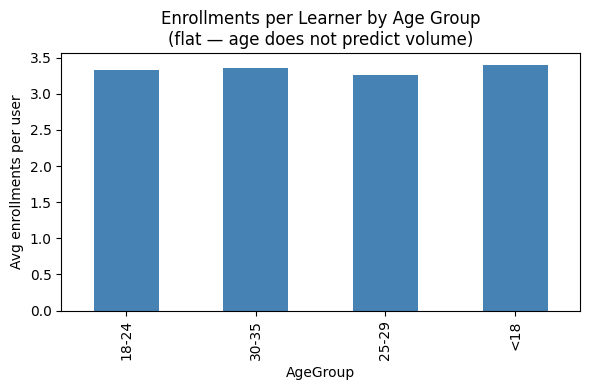

In [76]:
import matplotlib.pyplot as plt

# KPI 2: Age vs Enrollment Volume — plotting normalized rate, NOT raw counts,
# because raw counts are a bin-width artifact (already proven)
fig, ax = plt.subplots(figsize=(6,4))
enrollment_rate.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Enrollments per Learner by Age Group\n(flat — age does not predict volume)")
ax.set_ylabel("Avg enrollments per user")
plt.tight_layout()
plt.savefig("chart_age_rate.png", dpi=150)
plt.show()

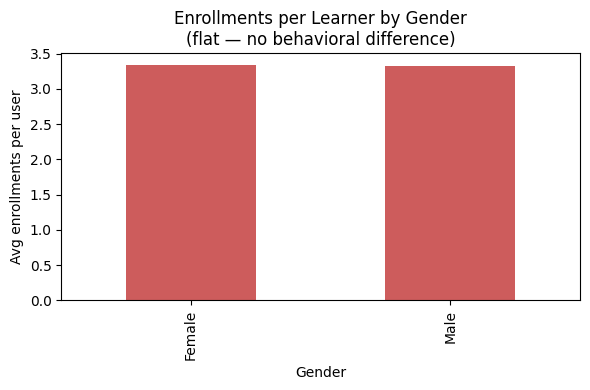

In [77]:
# KPI 3: Gender Participation — same logic, rate not raw count
fig, ax = plt.subplots(figsize=(6,4))
gender_rate.plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Enrollments per Learner by Gender\n(flat — no behavioral difference)")
ax.set_ylabel("Avg enrollments per user")
plt.tight_layout()
plt.savefig("chart_gender_rate.png", dpi=150)
plt.show()

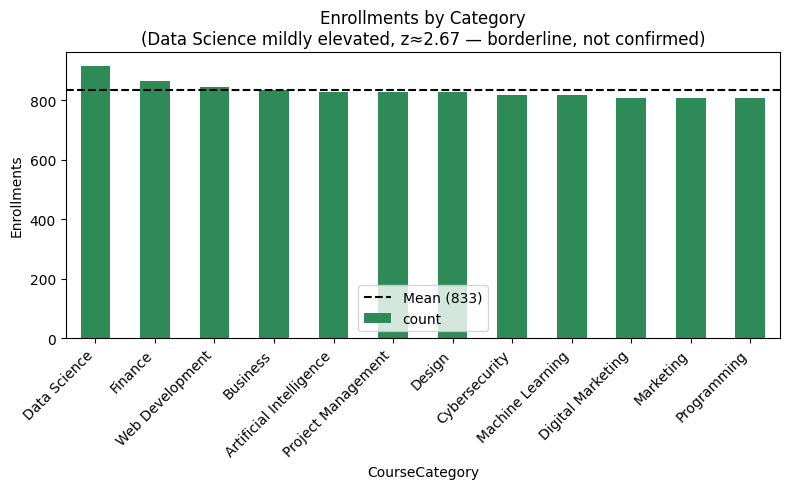

In [78]:
# KPI 4: Category Popularity — raw counts ARE valid here (equal course supply
# per category, unlike course level), but marking the mean line so the spread
# reads as "mild variation," not "clear winner"
fig, ax = plt.subplots(figsize=(8,5))
category_counts.plot(kind="bar", ax=ax, color="seagreen")
ax.axhline(cat_mean, color="black", linestyle="--", label=f"Mean ({cat_mean:.0f})")
ax.set_title("Enrollments by Category\n(Data Science mildly elevated, z≈2.67 — borderline, not confirmed)")
ax.set_ylabel("Enrollments")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_category.png", dpi=150)
plt.show()

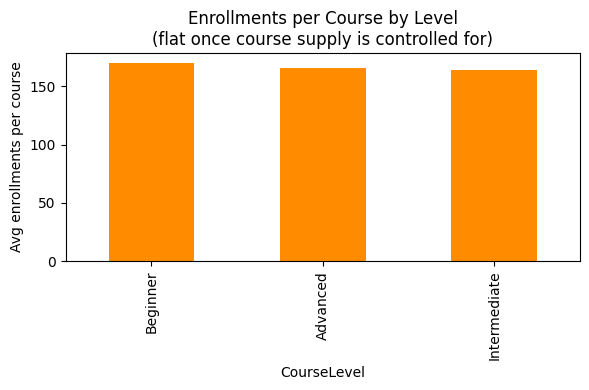

In [79]:
# KPI 5: Level Preference — plotting per-course rate, not raw totals,
# since raw totals are a course-supply artifact (18 vs 21 courses)
level_course_counts = courses["CourseLevel"].value_counts()
level_per_course = level_counts / level_course_counts
fig, ax = plt.subplots(figsize=(6,4))
level_per_course.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Enrollments per Course by Level\n(flat once course supply is controlled for)")
ax.set_ylabel("Avg enrollments per course")
plt.tight_layout()
plt.savefig("chart_level_rate.png", dpi=150)
plt.show()

In [80]:
# KPI 1: Total Enrollments — single-number KPI, no chart needed, but a
# simple text card for the dashboard/paper
print(f"Total Enrollments: {len(df):,}")
print(f"Total Users: {df['UserID'].nunique():,}")
print(f"Total Courses: {df['CourseID'].nunique():,}")

Total Enrollments: 10,000
Total Users: 3,000
Total Courses: 60


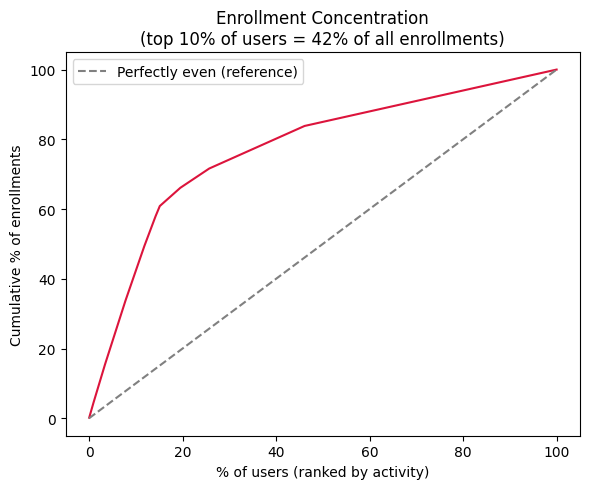

In [82]:
import numpy as np

# Strongest finding #1: Enrollment concentration - Lorenz-style cumulative share
sorted_counts = user_enrollment_counts.sort_values(ascending=False).values
cumulative = sorted_counts.cumsum() / sorted_counts.sum()
pct_users = (np.arange(1, len(cumulative)+1) / len(cumulative)) * 100

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(pct_users, cumulative*100, color="crimson")
ax.plot([0,100],[0,100], linestyle="--", color="gray", label="Perfectly even (reference)")
ax.set_title("Enrollment Concentration\n(top 10% of users = 42% of all enrollments)")
ax.set_xlabel("% of users (ranked by activity)")
ax.set_ylabel("Cumulative % of enrollments")
ax.legend()
plt.tight_layout()
plt.savefig("chart_concentration.png", dpi=150)
plt.show()

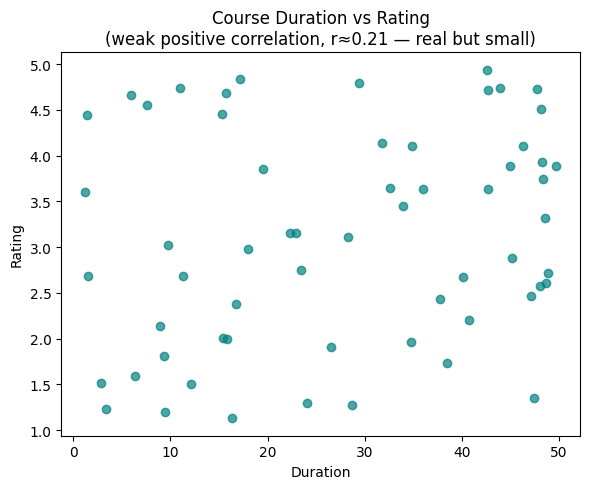

In [83]:
# Strongest finding #2: Duration vs Rating — weak but real, r≈0.21
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(courses["CourseDuration"], courses["CourseRating"], color="teal", alpha=0.7)
ax.set_title("Course Duration vs Rating\n(weak positive correlation, r≈0.21 — real but small)")
ax.set_xlabel("Duration")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.savefig("chart_duration_rating.png", dpi=150)
plt.show()

## KPI 1: Total Enrollments
**10,000 transactions across 3,000 users and 60 courses.**
Straightforward platform activity count. No behavioral claim attached.

## KPI 2: Enrollments by Age Group
Raw counts (18-24: 3272, 30-35: 2885, 25-29: 2374, <18: 1469) look uneven, but this
tracks group size, not engagement. Normalized per learner: 3.26–3.39 courses across
all age bands — a spread of 0.13, statistically flat. **Age does not predict enrollment volume.**

## KPI 3: Gender Participation Ratio
Platform is near-balanced: 50.7% Female, 49.3% Male by user count, and enrollment
rate matches (3.34 vs 3.33 courses/learner). Chi-square test on gender × course level:
p=0.906. **No behavioral difference by gender in this dataset.**

## KPI 4: Category Popularity Index
Data Science leads with 916 enrollments vs a 12-category mean of 833 (z≈2.67, ~4-5%
probability by chance alone). This is a borderline signal, not a confirmed trend — it
does not hold when tested against age subgroups (chi2 p=0.179). **Treat as a mild,
unconfirmed lead for further investigation, not a demand conclusion.**

## KPI 5: Level Preference Distribution
Raw counts favor Beginner (3573) over Intermediate (2952), but course supply is
uneven (21 Beginner/Advanced courses vs only 18 Intermediate). Normalized per course:
164–170 enrollments regardless of level — within 4%, effectively flat. **Level does
not predict demand once supply is controlled for.**

# EDA Findings Summary — EduPro Learner Analysis

**Dataset:**3,000 users, 60 courses, 10,000 transactions. Ages 15–35, gender ~50/50.

## Confirmed findings

**1. Enrollment concentration (strongest finding)**
Top 10% of users account for 42% of all enrollments — ~4x what random distribution would produce.
This is a behavioral finding, not demographic.

**2. Data Science category — borderline signal**
916 enrollments vs category mean of 833 (12 categories). z ≈ 2.67, ~4-5% chance by luck.
Does NOT hold when checked against age groups (chi2 p=0.179 — not significant).
Treat as weak, not conclusive.

**3. CourseDuration vs CourseRating — weak positive correlation**
r ≈ 0.21. Explains ~4% of rating variance. Real, but small.

## Null results (tested and ruled out)

| Test | Result |
|---|---|
| Age → enrollment volume | Flat (3.26–3.39 courses/learner across all bands) |
| Gender → enrollment volume | Flat (3.34 vs 3.33) |
| Age → category preference | Not significant (p=0.179) |
| Gender → course level | Not significant (p=0.906) |
| Course level → demand | Flat once normalized by course supply |
| Individual course popularity | No course statistically separates from the pack |
| Age/Price/Duration/Rating correlations | All near zero except Duration-Rating |

## Bottom line

Brief asked 4 demographic questions (age, gender, category, level effects). All 4 came back null.
Real story: a small subset of highly active users drives disproportionate volume; everything else is flat.
Report should be built around user concentration, not manufactured demographic segments.